In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)
data_dir = "/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime > Change runtime type > Hardware accelerator > GPU")

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

BATCH_SIZE = 32
NUM_WORKERS = 2

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_dataset = datasets.ImageFolder(
    root=f"{data_dir}/train",
    transform=train_transform
)

valid_full_dataset = datasets.ImageFolder(
    root=f"{data_dir}/valid",
    transform=eval_transform
)

valid_size = len(valid_full_dataset)
test_size = valid_size // 2
new_valid_size = valid_size - test_size

valid_dataset, test_dataset = random_split(
    valid_full_dataset,
    [new_valid_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

class_names = train_dataset.classes

print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))
print("Test size:", len(test_dataset))
print("Num classes:", len(class_names))

Train size: 70295
Valid size: 8786
Test size: 8786
Num classes: 38


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class PlantDiseaseVGGExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = self._make_block(3, 32)
        self.block2 = self._make_block(32, 64)
        self.block3 = self._make_block(64, 128)
        self.block4 = self._make_block(128, 256)
        self.block5 = self._make_block(256, 512)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.feature_dim = 512

    @staticmethod
    def _make_block(in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return x

In [ ]:
import numpy as np
import pandas as pd

def get_class_distribution(dataset, class_names):
    if hasattr(dataset, "samples"):
        labels = [label for _, label in dataset.samples]

    elif hasattr(dataset, "dataset") and hasattr(dataset, "indices"):
        labels = [dataset.dataset.samples[i][1] for i in dataset.indices]

    else:
        raise TypeError("Unsupported dataset type")

    counts = np.bincount(labels, minlength=len(class_names))

    df = pd.DataFrame({
        "class": class_names,
        "count": counts
    })

    df["percentage"] = 100 * df["count"] / df["count"].sum()

    return df.sort_values("count", ascending=False)

train_dist = get_class_distribution(train_dataset, class_names)
valid_dist = get_class_distribution(valid_dataset, class_names)
test_dist = get_class_distribution(test_dataset, class_names)

display(train_dist)
display(valid_dist)
display(test_dist)

train_dist.to_csv("train_class_distribution.csv", index=False)
valid_dist.to_csv("valid_class_distribution.csv", index=False)
test_dist.to_csv("test_class_distribution.csv", index=False)

,class,count,percentage
24,Soybean___healthy,2022,2.876449
0,Apple___Apple_scab,2016,2.867914
15,Orange___Haunglongbing_(Citrus_greening),2010,2.859378
3,Apple___healthy,2008,2.856533
19,"Pepper,_bell___healthy",1988,2.828082
1,Apple___Black_rot,1987,2.826659
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1961,2.789672
21,Potato___Late_blight,1939,2.758375
20,Potato___Early_blight,1939,2.758375
37,Tomato___healthy,1926,2.739882


,class,count,percentage
24,Soybean___healthy,269,3.061689
10,Corn_(maize)___healthy,266,3.027544
37,Tomato___healthy,262,2.982017
0,Apple___Apple_scab,259,2.947872
3,Apple___healthy,258,2.936490
1,Apple___Black_rot,255,2.902345
30,Tomato___Late_blight,252,2.868199
15,Orange___Haunglongbing_(Citrus_greening),249,2.834054
20,Potato___Early_blight,245,2.788527
18,"Pepper,_bell___Bacterial_spot",244,2.777145


,class,count,percentage
19,"Pepper,_bell___healthy",261,2.970635
8,Corn_(maize)___Common_rust_,255,2.902345
15,Orange___Haunglongbing_(Citrus_greening),254,2.890963
6,Cherry_(including_sour)___healthy,251,2.856818
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,249,2.834054
21,Potato___Late_blight,247,2.811291
29,Tomato___Early_blight,247,2.811291
0,Apple___Apple_scab,245,2.788527
3,Apple___healthy,244,2.777145
12,Grape___Esca_(Black_Measles),243,2.765764


In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

class ResNet18Extractor(nn.Module):
    def __init__(self, unfreeze_layers='layer4'):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = 512

        for p in self.features.parameters():
            p.requires_grad = False

        if unfreeze_layers == 'layer4':
            for p in self.features[-2].parameters():
                p.requires_grad = True
        elif unfreeze_layers == 'layer3_layer4':
            for p in self.features[-3].parameters():
                p.requires_grad = True
            for p in self.features[-2].parameters():
                p.requires_grad = True
        elif unfreeze_layers == 'all':
            for p in self.features.parameters():
                p.requires_grad = True

    def forward(self, x):
        x = self.features(x)
        return torch.flatten(x, 1)

In [ ]:
class HybridFusionModel(nn.Module):
    def __init__(self, num_classes=38, resnet_unfreeze='layer4', dropout=0.4):
        super().__init__()
        self.cnn_extractor    = PlantDiseaseVGGExtractor()
        self.resnet_extractor = ResNet18Extractor(unfreeze_layers=resnet_unfreeze)

        fused_dim = self.cnn_extractor.feature_dim + self.resnet_extractor.feature_dim  # 512 + 512 = 1024

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(fused_dim),
            nn.Linear(fused_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        cnn_feats    = self.cnn_extractor(x)     # (B, 512)
        resnet_feats = self.resnet_extractor(x)  # (B, 512)
        fused        = torch.cat([cnn_feats, resnet_feats], dim=1)  # (B, 1024)
        return self.classifier(fused)            # (B, 38) logits

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

def extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        if 'model_state_dict' in ckpt:
            state = ckpt['model_state_dict']
        elif 'state_dict' in ckpt:
            state = ckpt['state_dict']
        else:
            state = ckpt
    else:
        state = ckpt

    return {k.replace('module.', ''): v for k, v in state.items()}


def load_pretrained_branches(model, cnn_ckpt_path, resnet_ckpt_path, device):
    if os.path.exists(cnn_ckpt_path):
        ckpt = torch.load(cnn_ckpt_path, map_location='cpu')
        full_state = extract_state_dict(ckpt)

        extractor_state = {
            k: v for k, v in full_state.items()
            if not (
                k.startswith('fc2') or
                k.startswith('fc_out') or
                k.startswith('classifier')
            )
        }

        missing, unexpected = model.cnn_extractor.load_state_dict(extractor_state, strict=True)

        print("CNN checkpoint yüklendi.")
        print("CNN missing keys:", missing)
        print("CNN unexpected keys:", unexpected)
    else:
        print("CNN checkpoint bulunamadı -> CNN branch sıfırdan / mevcut init ile devam edecek.")

    if os.path.exists(resnet_ckpt_path):
        ckpt = torch.load(resnet_ckpt_path, map_location='cpu')
        full_state = extract_state_dict(ckpt)

        temp_resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
        temp_resnet.fc = nn.Linear(temp_resnet.fc.in_features, 38)

        missing_tmp, unexpected_tmp = temp_resnet.load_state_dict(full_state, strict=True)

        temp_extractor_state = nn.Sequential(*list(temp_resnet.children())[:-1]).state_dict()
        missing, unexpected = model.resnet_extractor.features.load_state_dict(
            temp_extractor_state, strict=True
        )

        print("ResNet checkpoint yüklendi.")
        print("Temp ResNet missing keys:", missing_tmp)
        print("Temp ResNet unexpected keys:", unexpected_tmp)
        print("ResNet extractor missing keys:", missing)
        print("ResNet extractor unexpected keys:", unexpected)
    else:
        print("ResNet checkpoint bulunamadı -> ResNet branch torchvision pretrained ağırlıklarıyla devam edecek.")

    model = model.to(device)
    print("Model hazır:", device)
    return model

In [ ]:
def make_optimizer(model, optimizer_name, lr, weight_decay):
    params = filter(lambda p: p.requires_grad, model.parameters())

    if optimizer_name.lower() == "adam":
        return optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "adamw":
        return optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

In [ ]:
from sklearn.metrics import f1_score

def train_one_config(
    config,
    train_loader,
    valid_loader,
    class_names,
    device,
    save_dir="experiment_runs"
):
    os.makedirs(save_dir, exist_ok=True)

    use_amp = torch.cuda.is_available()

    CNN_CHECKPOINT = "/content/best.pth"
    RESNET_CHECKPOINT = "/content/best_model.pth"


    model = HybridFusionModel(
        num_classes=38,
        resnet_unfreeze=config["resnet_unfreeze"],
        dropout=config["dropout"]
    )
    model = load_pretrained_branches(model, CNN_CHECKPOINT, RESNET_CHECKPOINT, device)


    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        model,
        optimizer_name=config["optimizer"],
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)


    num_epochs = config["epochs"]
    best_val_f1 = -1.0
    best_epoch = -1

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": []
    }

    run_name = (
        f"opt-{config['optimizer']}_"
        f"lr-{config['lr']}_"
        f"wd-{config['weight_decay']}_"
        f"drop-{config['dropout']}_"
        f"resnet-{config['resnet_unfreeze']}"
    ).replace("/", "-")

    best_model_path = os.path.join(save_dir, f"{run_name}.pth")

    print(f"\nSTART RUN: {run_name}")

    for epoch in range(num_epochs):
        print(f"Epoch: {epoch}")

        model.train()
        run_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            run_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

        t_loss = run_loss / total
        t_acc = 100 * correct / total
        t_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

        # VALID
        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)

                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                run_loss += loss.item() * images.size(0)
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += images.size(0)

                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

        v_loss = run_loss / total
        v_acc = 100 * correct / total
        v_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["train_f1"].append(t_f1)
        history["val_f1"].append(v_f1)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {t_loss:.4f} | Acc: {t_acc:.2f}% | F1: {t_f1:.2f}% || "
            f"Val Loss: {v_loss:.4f} | Acc: {v_acc:.2f}% | F1: {v_f1:.2f}%"
        )

        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            best_epoch = epoch + 1
            torch.save({
                "model_state_dict": model.state_dict(),
                "history": history,
                "class_names": class_names,
                "config": config,
                "best_val_f1": best_val_f1,
                "best_epoch": best_epoch
            }, best_model_path)

            print(f"  >> Best model saved (Val F1: {v_f1:.2f}%)")

    result = {
        "run_name": run_name,
        "best_model_path": best_model_path,
        "best_val_f1": best_val_f1,
        "best_epoch": best_epoch,
        "config": copy.deepcopy(config),
        "final_val_f1": history["val_f1"][-1],
        "final_val_acc": history["val_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
    }

    print(f"END RUN: {run_name} | BEST VAL F1: {best_val_f1:.2f}% at epoch {best_epoch} \n")
    return result

In [ ]:
def run_ordered_experiments(
    experiment_name,
    values,
    base_config,
    key_to_change,
    train_loader,
    valid_loader,
    class_names,
    device,
    save_dir="experiment_runs"
):
    results = []
    print(f"\nEXPERIMENT: {experiment_name}")

    for value in values:
        config = copy.deepcopy(base_config)
        config[key_to_change] = value
        print(f"\n--- Testing {key_to_change} = {value} ---")

        result = train_one_config(
            config=config,
            train_loader=train_loader,
            valid_loader=valid_loader,
            class_names=class_names,
            device=device,
            save_dir=save_dir
        )
        results.append(result)

    results = sorted(results, key=lambda x: x["best_val_f1"], reverse=True)

    print(f"\nRESULTS: {experiment_name}")
    for i, r in enumerate(results, 1):
        print(
            f"{i}. {key_to_change}={r['config'][key_to_change]} | "
            f"Best Val F1={r['best_val_f1']:.2f}% | "
            f"Best Epoch={r['best_epoch']} | "
            f"Run={r['run_name']}"
        )

    return results

In [ ]:
import copy
import torch

import torch.nn as nn

import torch.optim as optim

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
import copy

base_config = {
    "optimizer": "adamw",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "dropout": 0.4,
    "resnet_unfreeze": "layer4",
    "epochs": 5
}

# 1. Learning rate tuning
lr_results = run_ordered_experiments(
    experiment_name="Learning Rate Tuning",
    values=[1e-3, 3e-4, 1e-4, 3e-5],
    base_config=base_config,
    key_to_change="lr",
    train_loader=train_loader,
    valid_loader=valid_loader,
    class_names=class_names,
    device=device,
    save_dir="experiment_runs/lr_tuning"
)

best_config = copy.deepcopy(lr_results[0]["config"])

# 2. Dropout tuning
dropout_results = run_ordered_experiments(
    experiment_name="Dropout Tuning",
    values=[0.2, 0.3, 0.4, 0.5],
    base_config=best_config,
    key_to_change="dropout",
    train_loader=train_loader,
    valid_loader=valid_loader,
    class_names=class_names,
    device=device,
    save_dir="experiment_runs/dropout_tuning"
)

best_config = copy.deepcopy(dropout_results[0]["config"])

# 3. Weight decay tuning
wd_results = run_ordered_experiments(
    experiment_name="Weight Decay Tuning",
    values=[0, 1e-5, 1e-4, 1e-3],
    base_config=best_config,
    key_to_change="weight_decay",
    train_loader=train_loader,
    valid_loader=valid_loader,
    class_names=class_names,
    device=device,
    save_dir="experiment_runs/weight_decay_tuning"
)

best_config = copy.deepcopy(wd_results[0]["config"])

# 4. Optimizer tuning
optimizer_results = run_ordered_experiments(
    experiment_name="Optimizer Tuning",
    values=["adam", "adamw"],
    base_config=best_config,
    key_to_change="optimizer",
    train_loader=train_loader,
    valid_loader=valid_loader,
    class_names=class_names,
    device=device,
    save_dir="experiment_runs/optimizer_tuning"
)

best_config = copy.deepcopy(optimizer_results[0]["config"])

# 5. ResNet unfreeze tuning
unfreeze_results = run_ordered_experiments(
    experiment_name="ResNet Unfreeze Tuning",
    values=[None, "layer4", "layer3_layer4", "all"],
    base_config=best_config,
    key_to_change="resnet_unfreeze",
    train_loader=train_loader,
    valid_loader=valid_loader,
    class_names=class_names,
    device=device,
    save_dir="experiment_runs/resnet_unfreeze_tuning"
)

best_config = copy.deepcopy(unfreeze_results[0]["config"])

print("\nBEST CONFIG AFTER TUNING:")
print(best_config)

# 6. Final longer training
final_config = copy.deepcopy(best_config)
final_config["epochs"] = 10

final_result = train_one_config(
    config=final_config,
    train_loader=train_loader,
    valid_loader=valid_loader,
    class_names=class_names,
    device=device,
    save_dir="experiment_runs/final_model"
)

print("\nFINAL RESULT:")
print(final_result)


########## EXPERIMENT: Learning Rate Tuning ##########

--- Testing lr = 0.001 ---
CNN checkpoint yüklendi.
CNN missing keys: []
CNN unexpected keys: []
ResNet checkpoint yüklendi.
Temp ResNet missing keys: []
Temp ResNet unexpected keys: []
ResNet extractor missing keys: []
ResNet extractor unexpected keys: []
Model hazır: cuda

===== START RUN: opt-adamw_lr-0.001_wd-0.0001_drop-0.4_resnet-layer4 =====
Epoch: 0
Epoch [1/5] Train Loss: 0.1515 | Acc: 96.35% | F1: 96.33% || Val Loss: 0.0868 | Acc: 98.16% | F1: 98.13%
  >> Best model saved (Val F1: 98.13%)
Epoch: 1
Epoch [2/5] Train Loss: 0.0972 | Acc: 97.95% | F1: 97.94% || Val Loss: 0.0238 | Acc: 99.40% | F1: 99.39%
  >> Best model saved (Val F1: 99.39%)
Epoch: 2
Epoch [3/5] Train Loss: 0.0768 | Acc: 98.27% | F1: 98.27% || Val Loss: 0.0451 | Acc: 99.02% | F1: 99.03%
Epoch: 3
Epoch [4/5] Train Loss: 0.0615 | Acc: 98.66% | F1: 98.65% || Val Loss: 0.0252 | Acc: 99.47% | F1: 99.46%
  >> Best model saved (Val F1: 99.46%)
Epoch: 4
Epoch [5/5

In [ ]:
@torch.no_grad()
def evaluate_detailed(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, macro_f1, all_labels, all_preds

In [ ]:
from google.colab import files

!zip -r hybrid_fusion_outputs.zip experiment_runs final_runs best.pth best_model.pth train_class_distribution.csv valid_class_distribution.csv

files.download("hybrid_fusion_outputs.zip")

	zip warning: name not matched: final_runs
  adding: experiment_runs/ (stored 0%)
  adding: experiment_runs/weight_decay_tuning/ (stored 0%)
  adding: experiment_runs/weight_decay_tuning/opt-adamw_lr-3e-05_wd-0.0001_drop-0.5_resnet-layer4.pth (deflated 7%)
  adding: experiment_runs/weight_decay_tuning/opt-adamw_lr-3e-05_wd-0.001_drop-0.5_resnet-layer4.pth (deflated 7%)
  adding: experiment_runs/weight_decay_tuning/opt-adamw_lr-3e-05_wd-1e-05_drop-0.5_resnet-layer4.pth (deflated 7%)
  adding: experiment_runs/weight_decay_tuning/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-layer4.pth (deflated 7%)
  adding: experiment_runs/resnet_unfreeze_tuning/ (stored 0%)
  adding: experiment_runs/resnet_unfreeze_tuning/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-layer3_layer4.pth (deflated 7%)
  adding: experiment_runs/resnet_unfreeze_tuning/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-None.pth (deflated 7%)
  adding: experiment_runs/resnet_unfreeze_tuning/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-layer4.pth (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

best_hybrid_path = "/content/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-layer4.pth"

best_model = HybridFusionModel(
    num_classes=len(class_names),
    resnet_unfreeze="layer4",
    dropout=0.5
).to(device)

checkpoint = torch.load(best_hybrid_path, map_location=device)
best_model.load_state_dict(checkpoint["model_state_dict"], strict=True)

criterion = nn.CrossEntropyLoss()

test_loss, test_acc, test_f1, y_true_test, y_pred_test = evaluate_detailed(
    best_model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Macro F1: {test_f1 * 100:.2f}%")

KeyboardInterrupt: 

In [ ]:
report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

with open("hybrid_classification_report.txt", "w") as f:
    f.write(report)


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9959    0.9980       245
                                 Apple___Black_rot     1.0000    1.0000    1.0000       242
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       206
                                   Apple___healthy     0.9959    1.0000    0.9980       244
                               Blueberry___healthy     1.0000    0.9953    0.9977       215
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       214
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000       251
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9953    0.9860    0.9907       215
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       255
               Corn_(maize)___Northern_Leaf_Blight     0.9874    0.9958    0.99

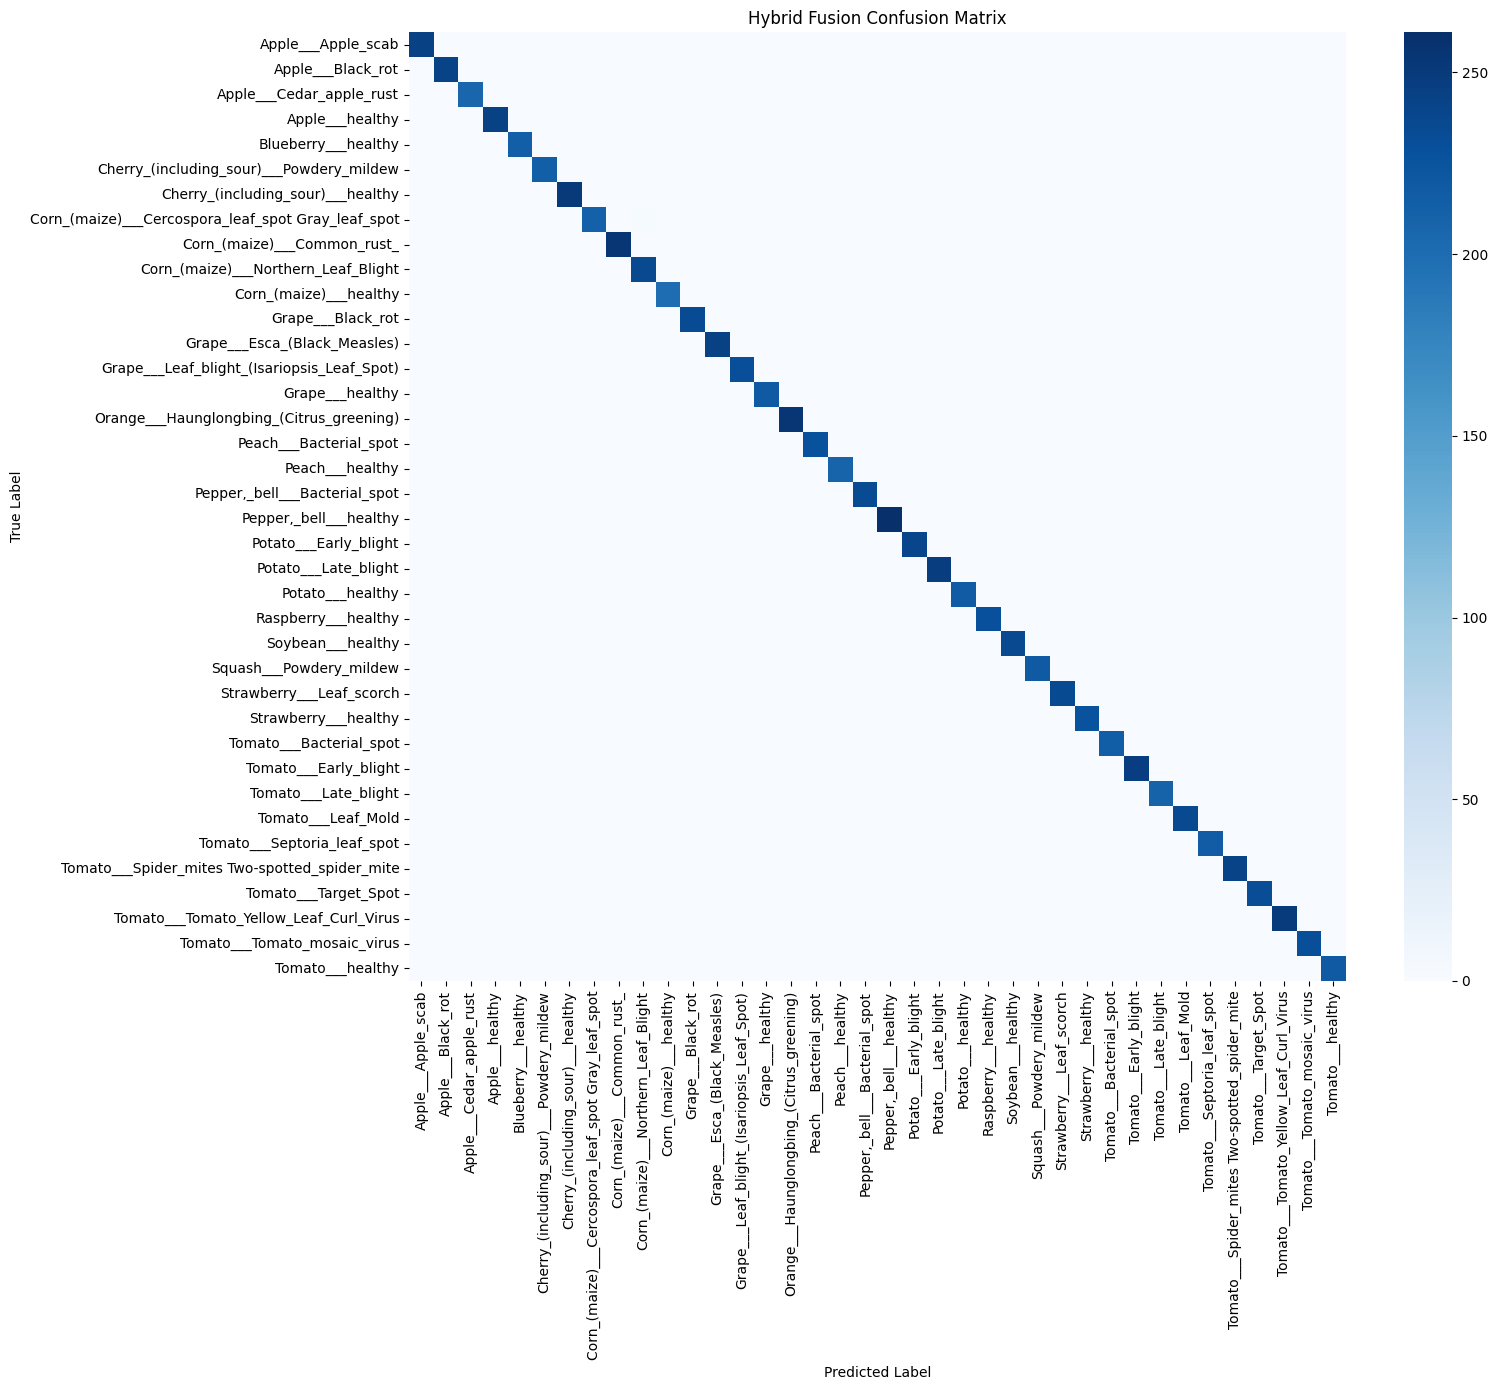

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Hybrid Fusion Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("hybrid_confusion_matrix.png", dpi=300)
plt.show()


In [ ]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

mistakes = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):
        count = cm_no_diag[true_idx, pred_idx]
        if count > 0:
            mistakes.append({
                "true_class": class_names[true_idx],
                "predicted_class": class_names[pred_idx],
                "count": count
            })

mistakes_df = pd.DataFrame(mistakes).sort_values("count", ascending=False)

display(mistakes_df.head(15))
mistakes_df.to_csv("hybrid_top_misclassifications.csv", index=False)


,true_class,predicted_class,count
2,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,3
0,Apple___Apple_scab,Apple___healthy,1
1,Blueberry___healthy,"Pepper,_bell___healthy",1
3,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,1
4,Tomato___Early_blight,Tomato___Late_blight,1
5,Tomato___Late_blight,Tomato___healthy,1


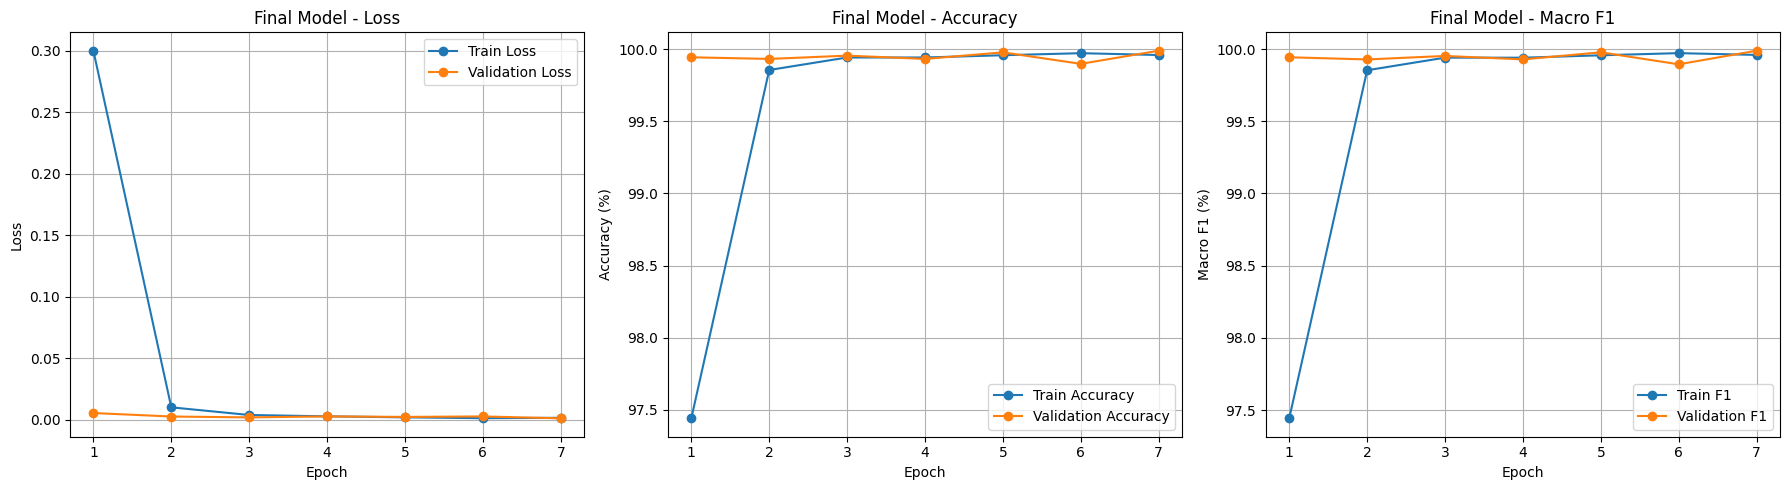

In [ ]:
import torch
import matplotlib.pyplot as plt

checkpoint_path = "/content/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-layer4.pth"

checkpoint = torch.load(checkpoint_path, map_location="cpu")
history = checkpoint["history"]

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model - Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Final Model - Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(epochs, history["train_f1"], marker="o", label="Train F1")
plt.plot(epochs, history["val_f1"], marker="o", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1 (%)")
plt.title("Final Model - Macro F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("final_model_training_plots.png", dpi=300)
plt.show()


In [ ]:
import torch
import pandas as pd

checkpoint_paths = {
    "Frozen / None": "/content/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-None.pth",
    "Layer4": "/content/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-layer4.pth",
    "Layer3 + Layer4": "/content/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-layer3_layer4.pth",
    "All Layers": "/content/opt-adamw_lr-3e-05_wd-0_drop-0.5_resnet-all.pth",
}


In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

checkpoint_paths = {
    "LR = 1e-3": "/content/opt-adamw_lr-0.001_wd-0.0001_drop-0.4_resnet-layer4.pth",
    "LR = 3e-4": "/content/opt-adamw_lr-0.0003_wd-0.0001_drop-0.4_resnet-layer4.pth",
    "LR = 1e-4": "/content/opt-adamw_lr-0.0001_wd-0.0001_drop-0.4_resnet-layer4.pth",
    "LR = 3e-5": "/content/opt-adamw_lr-3e-05_wd-0.0001_drop-0.4_resnet-layer4.pth",
}


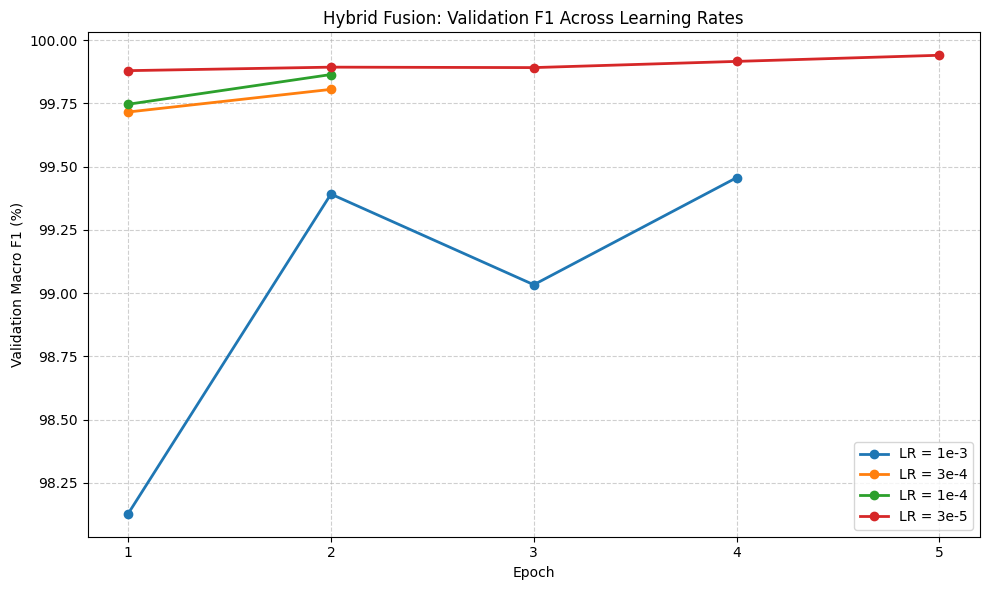

In [ ]:
plt.figure(figsize=(10, 6))

for setting, path in checkpoint_paths.items():
    checkpoint = torch.load(path, map_location="cpu")
    history = checkpoint["history"]

    epochs = range(1, len(history["val_f1"]) + 1)

    plt.plot(
        epochs,
        history["val_f1"],
        marker="o",
        linewidth=2,
        label=setting
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1 (%)")
plt.title("Hybrid Fusion: Validation F1 Across Learning Rates")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("learning_rate_val_f1_curves.png", dpi=300)
plt.show()


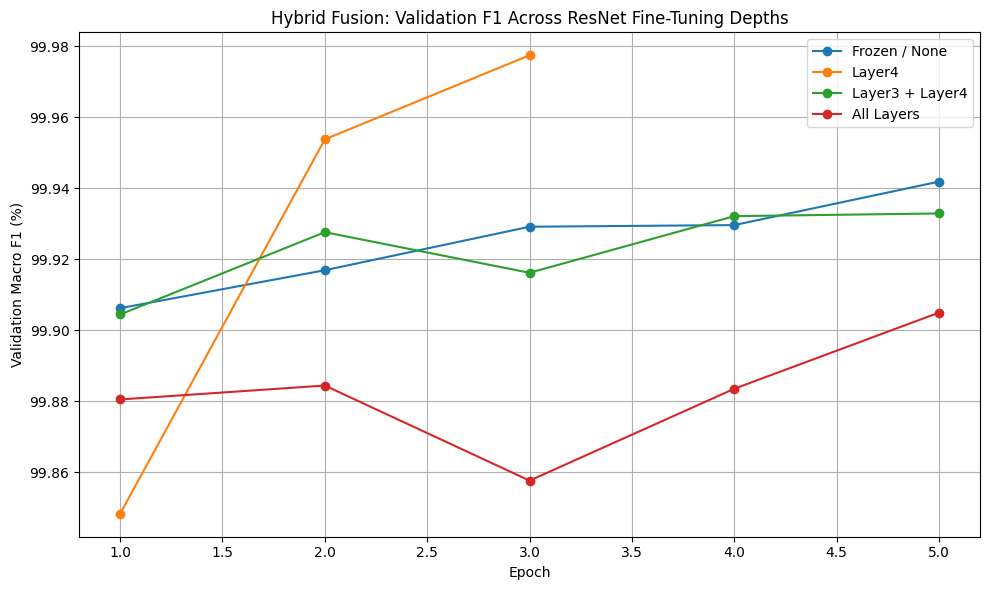

In [ ]:
plt.figure(figsize=(10, 6))

for setting, path in checkpoint_paths.items():
    checkpoint = torch.load(path, map_location="cpu")
    history = checkpoint["history"]

    epochs = range(1, len(history["val_f1"]) + 1)

    plt.plot(
        epochs,
        history["val_f1"],
        marker="o",
        label=setting
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1 (%)")
plt.title("Hybrid Fusion: Validation F1 Across ResNet Fine-Tuning Depths")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("resnet_layerwise_val_f1_curves.png", dpi=300)
plt.show()
